<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/first_neural_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GPU, Datasets, Dataloaders, Transforms, Neural Net, Training and Evaluation

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Device configuration
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(device)

cuda


In [4]:
# Hyperparameters
# MNIST dataset
# images of size 28 by 28
input_size = 784
hidden_size = 500
num_classes = 10 # We have 10 different digits
num_epochs = 2
batch_size = 100
learning_rate = 0.001

In [5]:
# MNIST Dataset
# transform (callable, optional): A function/transform that  takes in a PIL image
    #     and returns a transformed version. E.g, transforms.RandomCrop
    # target_transform (callable, optional): A function/transform that takes in the
    #     target and transforms it.


train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.17MB/s]


In [6]:
print(train_dataset.classes)
print(type(train_dataset.classes))

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
<class 'list'>


In [7]:
print(train_dataset.data)

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [8]:
print(train_dataset.transforms)

StandardTransform
Transform: ToTensor()


In [9]:
print(train_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [10]:
print(train_dataset.data.shape)

torch.Size([60000, 28, 28])


In [11]:
print(test_dataset.data.shape)

torch.Size([10000, 28, 28])


In [12]:
# Dataloaders

In [13]:
train_dataloader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [14]:
print(train_dataloader)

In [15]:
print(train_dataloader.batch_sampler)
print(train_dataloader.batch_size)
print(train_dataloader.collate_fn)
print(train_dataloader.dataset)
print(train_dataloader.drop_last)
print(train_dataloader.pin_memory)
print(train_dataloader.sampler)

100
<function default_collate at 0x784e2856f740>
Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
False
False


In [16]:
in1 = np.arange(1,13, dtype=np.float32)
print(in1)
print(in1.shape)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
(12,)


In [17]:
in2 = torch.from_numpy(in1)
print(in2)
print(in2.shape)

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])
torch.Size([12])


In [18]:
in3 = in2.view(3,2,2)
print(in3)
print(in3.shape)

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])
torch.Size([3, 2, 2])


In [19]:
in_dataset = torch.utils.data.TensorDataset(in3)
print(in_dataset)

In [20]:
print(in_dataset.tensors)

(tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]]),)


In [21]:
in_dataloader = torch.utils.data.DataLoader(
    dataset=in_dataset,
    batch_size=2,
    shuffle=False
)
print(in_dataloader)

In [22]:
print(in_dataloader.dataset.tensors)
print(in_dataloader.batch_size)
print(in_dataloader.drop_last)
print(in_dataloader.sampler.data_source.tensors[0])

(tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]]),)
2
False
tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])


In [23]:
print(in_dataloader.dataset.tensors[0])

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])


In [24]:
print(type(train_dataset))

<class 'torchvision.datasets.mnist.MNIST'>


In [25]:
from torch.utils.data import TensorDataset

tensor_input_data = torch.randn(1000, 15, 2)
my_dataset = TensorDataset(tensor_input_data)


In [26]:
print(my_dataset.tensors[0].shape)

torch.Size([1000, 15, 2])


In [27]:
print(in_dataset.tensors[0].shape)

torch.Size([3, 2, 2])


In [28]:
my_list = [1, 2, 3]
my_iterator = iter(my_list)

print(next(my_iterator))
print(next(my_iterator))
print(next(my_iterator))

try:
    print(next(my_iterator))
except StopIteration:
    print("End of iterator")


1
2
3
End of iterator


In [29]:
print(test_dataloader)
print(type(test_dataloader))
print(test_dataloader.batch_sampler)
print(test_dataloader.batch_size)
print(test_dataloader.collate_fn)
print(test_dataloader.dataset)
print(test_dataloader.drop_last)
print(test_dataloader.pin_memory)

<class 'torch.utils.data.dataloader.DataLoader'>
100
<function default_collate at 0x784e2856f740>
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()
False
False


In [30]:
print(test_dataloader.dataset.data.shape)

torch.Size([10000, 28, 28])


In [31]:
examples = iter(test_dataloader)
print(examples)

In [32]:
print(len(examples))

100


In [33]:
example_features, examples_labels = next(examples)
print(example_features.shape)
print(examples_labels.shape)

torch.Size([100, 1, 28, 28])
torch.Size([100])


In [34]:
# There are 100 matrices
# In each matrix, we have 1 matrix
# This matrix contains 28 rows and 28 columns

In [35]:
# print(example_features[0])

In [36]:
print(examples_labels[0])

tensor(7)


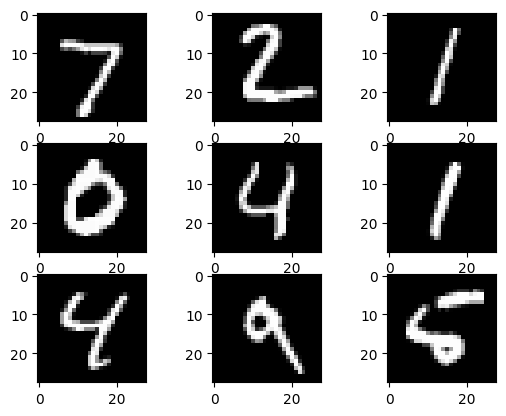

In [37]:
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(example_features[i][0], cmap='gray')

In [38]:
print("Hello")

Hello


In [39]:
print(torch)

<module 'torch' from '/usr/local/lib/python3.11/dist-packages/torch/__init__.py'>


In [40]:
# Fully connected Neural Network with 1 hidden layer
class FullyConnectedNeuralNetwork(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim):
     super().__init__()
     self.l1 = nn.Linear(input_dim, hidden_dim)
     self.relu = nn.ReLU() # activation function
     self.l2 = nn.Linear(hidden_dim, output_dim)
  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    # No activation or softmax at the end
    return out

In [41]:
fcnn = FullyConnectedNeuralNetwork(input_size, hidden_size, num_classes).to(device)

In [42]:
print(fcnn)

FullyConnectedNeuralNetwork(
  (l1): Linear(in_features=784, out_features=500, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=500, out_features=10, bias=True)
)


In [43]:

print(device)

cuda


In [44]:
# Define loss and gradient descent
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fcnn.parameters(), lr=learning_rate)
print(loss)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [45]:
print(fcnn.parameters())

<generator object Module.parameters at 0x784d543f0ac0>


In [46]:
for value in fcnn.parameters():
    # print(value)
    print(value.shape)
    # print(value[0].item())


torch.Size([500, 784])
torch.Size([500])
torch.Size([10, 500])
torch.Size([10])


In [47]:
# So there are total 4 parameters that will be optimized
# w1, b1 for layer1 and w2, b2 for layer2 or output layer
# Size of w1 can be derived from wx
# We have 784 features, and n number of examples
# The input vector to hidden layer contains n examples, each of size 784
# There are total 500 neurons in the hidden layer
# Dimension of X = [1, 784]
# Dimensions of hidden layer = 500
# For matrix multiplication of w.x
# [500, n].[n, 784]
# Therefor w's dimension would be [500,784]
# And b would be a scalar of value 500
# This is because we take a transpose of the matrix, so w.xT
# xT = [784, n]
# w.xT = [500,784].[784,n] = [500, n]

In [48]:
# training loop
number_of_examples = len(train_dataloader)
print(number_of_examples)

600


In [49]:
for epoch in range(num_epochs):
  for i, (training_sample, labels) in enumerate(train_dataloader):
    # print(type(training_sample), training_sample.shape) [100, 1, 28, 28]
    # print(type(labels), labels.shape) [100]
    training_sample = training_sample.view(-1, 28*28).to(device)
    labels = labels.to(device)

    # Forward pass
    y_pred = fcnn(training_sample)

    # Loss
    l = loss(y_pred, labels)

    # Gradient descent
    l.backward()

    # Update weights
    optimizer.step()

    # Zero gradients
    optimizer.zero_grad()

    if (i+1) % 100 == 0:
      w1, b1, w2, b2 = fcnn.parameters()
      print(f"epoch({epoch+1}); step({(i+1)}/{number_of_examples}); loss({l.item()})")
      # break


epoch(1); step(100/600); loss(0.19636540114879608)
epoch(1); step(200/600); loss(0.24397830665111542)
epoch(1); step(300/600); loss(0.2845349609851837)
epoch(1); step(400/600); loss(0.1859479397535324)
epoch(1); step(500/600); loss(0.23204782605171204)
epoch(1); step(600/600); loss(0.12778975069522858)
epoch(2); step(100/600); loss(0.09778659790754318)
epoch(2); step(200/600); loss(0.10081560909748077)
epoch(2); step(300/600); loss(0.11481036990880966)
epoch(2); step(400/600); loss(0.10023287683725357)
epoch(2); step(500/600); loss(0.06804652512073517)
epoch(2); step(600/600); loss(0.06714407354593277)


In [50]:
w1, b1, w2, b2 = fcnn.parameters()

In [56]:
for i, (training_sample, labels) in enumerate(train_dataloader):
    # print(type(training_sample), training_sample.shape) [100, 1, 28, 28]
    # print(type(labels), labels.shape) [100]
    training_sample = training_sample.view(-1, 28*28).to(device)
    print(training_sample.shape)
    break
    # labels = labels.to(device)

    # # Forward pass
    # y_pred = fcnn(training_sample

torch.Size([100, 784])


In [57]:
# Apply these weights to new dataset
# this is a multi-class classification problem

In [84]:
number_training_sample_test = len(test_dataloader.dataset)
print(number_training_sample_test)

10000


In [68]:
x = torch.tensor([[1, 5, 2], [8, 3, 9]])
max_values, max_indices = torch.max(x, 1)
print(max_values)  # Output: tensor([5, 9])
print(max_indices) # Output: tensor([1, 2])
# Dimension = 0: returns max for each column
# Dimension = 1: returns max for each row

tensor([5, 9])
tensor([1, 2])


In [91]:
# We don't need to learn anything here, so set gradient learning to false
with torch.no_grad():
  number_correct = 0
  number_training_sample_test = len(test_dataloader.dataset)
  print(number_training_sample_test)
  # number_samples = 0
  # We don't need any batch information here
  for training_sample, labels in test_dataloader:
    # print(labels[0].shape) [1, 28, 28]

    training_sample = training_sample.view(-1, 28*28).to(device)
    # print(training_sample.shape) # Size [100, 784]
    labels = labels.to(device)
    # print(labels[0], labels[0].shape) # Value 7
    # print(torch.max(labels[0], 1))
    # break

    # Forward pass
    y_pred = fcnn(training_sample)

    # The predicted values are raw tensors, but our labels are index, number
    # To get the actual predicted values/classes, we use torch.max
    max_values, max_indices = torch.max(y_pred, 1) # We want max value for each row?
    # Now, both labels and y_pred are tensors
    # So we are comparing indices now
    # Sum of correct comparison on indices on 100 number
    number_correct += (max_indices == labels).sum().item()
    # print(max_indices.shape, labels.shape)
    # print(labels)
  accuracy = number_correct/number_training_sample_test
  print(f"Accuracy = {accuracy*100}%")


10000
Accuracy = 96.98%


In [82]:
print(test_dataloader.dataset)

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()
